In [1]:
#Importing the necessary Libraries for Time series  analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , mean_absolute_error


from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from scipy.signal import periodogram  #used for obtaining Spectral density values
!pip install pmdarima
from pmdarima import auto_arima
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    warnings.filterwarnings("ignore", category=UserWarning)


In [2]:
#Loading the data
#File path variables

Local_path = 'C:/Users/beatr/OneDrive/Desktop/WGU/D213/Task1/Data/'

InputFilePath = Local_path + 'teleco_time_series .csv'
CleanedFilePath= Local_path + 'Teleco_cleaned_time_series.csv'

TrainedDataFilePath= Local_path + 'Teleco_Train_data.csv'
TestDataFilePath= Local_path + 'Teleco_Test_data.csv'
Teleco_df = pd.read_csv(InputFilePath)

In [3]:
#Initial data exploration (Understanding the data)
pd.set_option('display.max_columns', None)
Teleco_df


,Day,Revenue
0,1,0.000000
1,2,0.000793
2,3,0.825542
3,4,0.320332
4,5,1.082554
...,...,...
726,727,16.931559
727,728,17.490666
728,729,16.803638
729,730,16.194813


In [4]:
Teleco_df.shape

(731, 2)

In [5]:
Teleco_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Day      731 non-null    int64  
 1   Revenue  731 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 11.6 KB


In [6]:
#Converting  day into datetime, creating index and sorting the data

Teleco_df['Date']=pd.to_datetime(Teleco_df['Day'],unit='D', origin='2023/07/31')
Teleco_df=Teleco_df[['Date','Revenue']]
Teleco_df=Teleco_df.set_index("Date")
Teleco_df=Teleco_df.sort_index()
Teleco_df = Teleco_df.asfreq("D")
Teleco_df = Teleco_df.asfreq(pd.infer_freq(Teleco_df.index))

print(Teleco_df.info())
Teleco_df

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 731 entries, 2023-08-01 to 2025-07-31
Freq: D
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Revenue  731 non-null    float64
dtypes: float64(1)
memory usage: 11.4 KB
None


,Revenue
Date,
2023-08-01,0.000000
2023-08-02,0.000793
2023-08-03,0.825542
2023-08-04,0.320332
2023-08-05,1.082554
...,...
2025-07-27,16.931559
2025-07-28,17.490666
2025-07-29,16.803638


<Axes: xlabel='Date'>

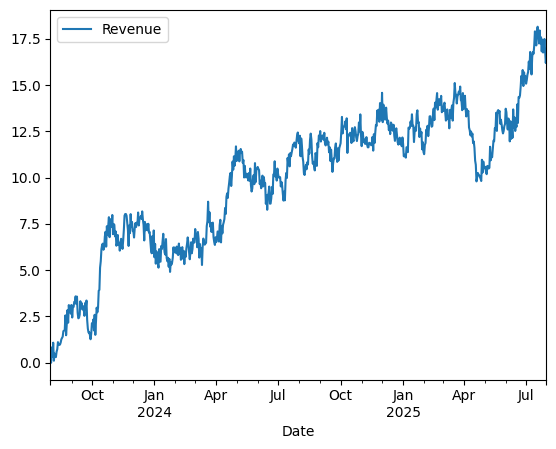

In [7]:
Teleco_df.plot()

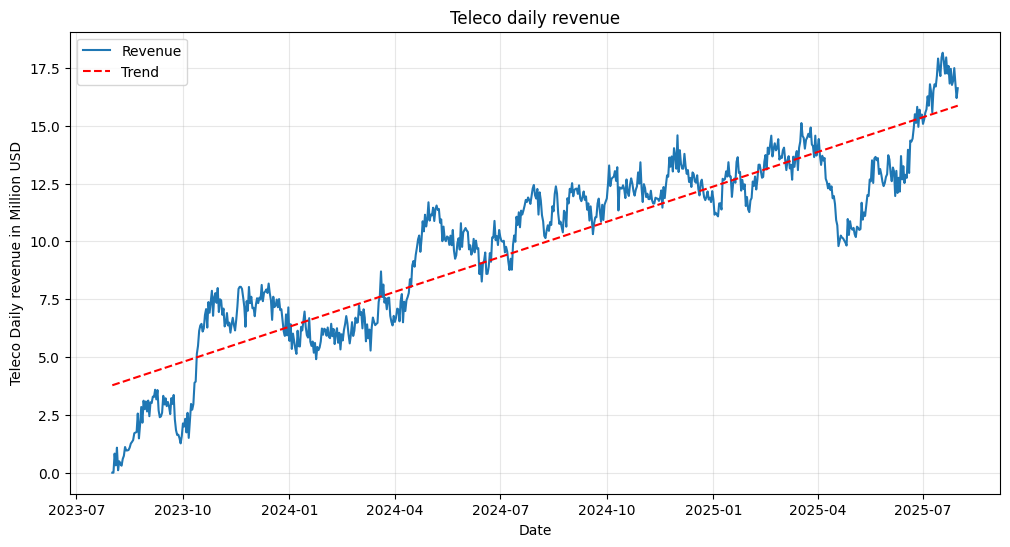

In [8]:
#LINE GRAPH VISUALIZATION
#Creating the initial time series graph to check for trend, seasonality,outlier
plt.figure(figsize=(12,6))
plt.plot(Teleco_df.index, Teleco_df, label="Revenue")

# Fitting the best line (polynomial) to the data
x = np.arange(len(Teleco_df['Revenue'].values))
y = Teleco_df['Revenue'].values

z = np.polyfit(x, y, 1)          
p = np.poly1d(z)
plt.plot(Teleco_df.index, p(x), color='red',linestyle='--',label='Trend')

plt.title("Teleco daily revenue")
plt.ylabel("Teleco Daily revenue in Million USD")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [9]:
#Teleco_df time step formatting
Teleco_df=Teleco_df.asfreq('D')
print(Teleco_df.index)
print(f"Start date: {Teleco_df.index.min()}")
print(f"End date: {Teleco_df.index.max()}")
print(f"Total days: {len(Teleco_df)}")
print(f"Frequency: {Teleco_df.index.freqstr}")


DatetimeIndex(['2023-08-01', '2023-08-02', '2023-08-03', '2023-08-04',
               '2023-08-05', '2023-08-06', '2023-08-07', '2023-08-08',
               '2023-08-09', '2023-08-10',
               ...
               '2025-07-22', '2025-07-23', '2025-07-24', '2025-07-25',
               '2025-07-26', '2025-07-27', '2025-07-28', '2025-07-29',
               '2025-07-30', '2025-07-31'],
              dtype='datetime64[ns]', name='Date', length=731, freq='D')
Start date: 2023-08-01 00:00:00
End date: 2025-07-31 00:00:00
Total days: 731
Frequency: D


In [10]:
#Detecting gaps
Teleco_gaps=Teleco_df[Teleco_df['Revenue'].isna()]
print(len(Teleco_gaps))

0


In [11]:
#Teleco Sequence Length 
Teleco_Sequence_Lenth = len(Teleco_df)
print(Teleco_Sequence_Lenth)

731


In [12]:
#Stationarity test using the ADF test. Using the AIC autolag  on the original data
Stationarity_Results = adfuller(Teleco_df['Revenue'].dropna())

labels = [
    "ADF Statistic",
    "p-value",
    "Used lags",
    "Number of observations",
    "Critical Values",
    "IC Best"
]

print("# Stationarity Test (ADF) Original data")
for label, value in zip(labels, Stationarity_Results):
    if label == "Critical Values":
        print(f"{label}:")
        for k, v in value.items():
            print(f"   {k}: {v:.4f}")
    else:
        print(f"{label}: {value}")
        



# Stationarity Test (ADF) Original data
ADF Statistic: -1.9246121573101838
p-value: 0.3205728150793964
Used lags: 1
Number of observations: 729
Critical Values:
   1%: -3.4394
   5%: -2.8655
   10%: -2.5689
IC Best: 965.0609576707513


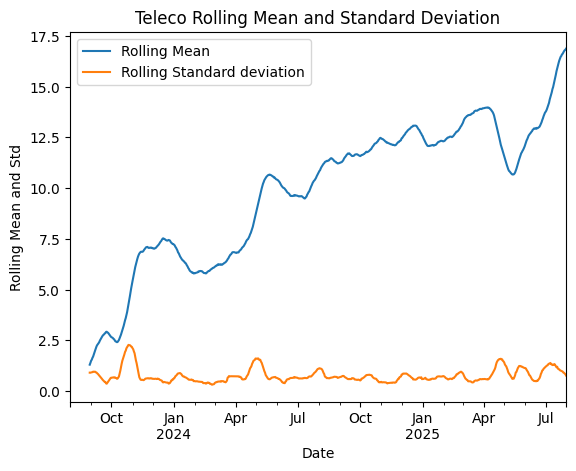

In [13]:
#Confirming the non stationarity using the rolling means
rolling_mean = Teleco_df['Revenue'].rolling(window=30).mean()
rolling_std = Teleco_df['Revenue'].rolling(window=30).std()

rolling_mean.plot(label='Rolling Mean')
rolling_std.plot(label='Rolling Standard deviation')
plt.ylabel("Rolling Mean and Std")
plt.legend()
plt.title('Teleco Rolling Mean and Standard Deviation')
plt.show()


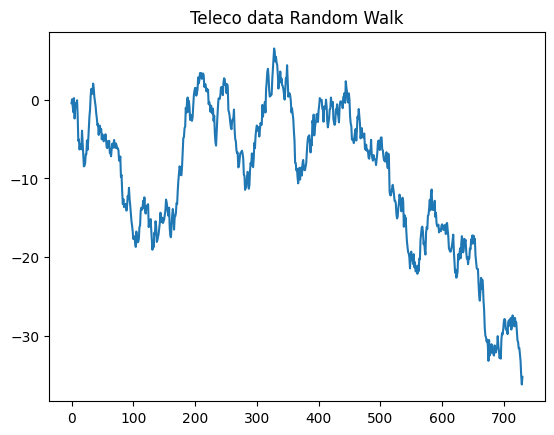

In [14]:
#random walk
#White noise is pure randomness. Random walk is a path where each step is random but depends on the previous one.
random_walk = np.cumsum(np.random.normal(0, 1, len(Teleco_df)))
plt.plot(random_walk)
plt.title('Teleco data Random Walk')
plt.show()

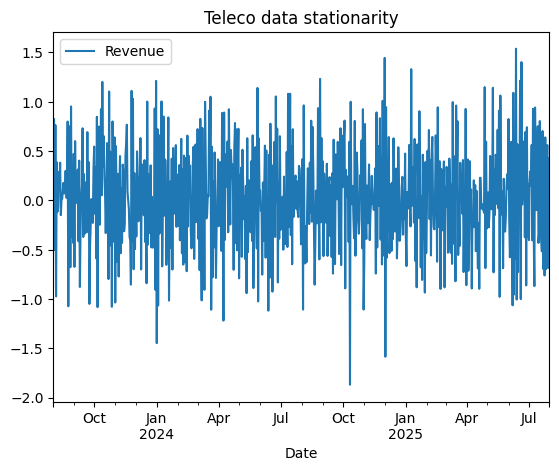

In [15]:
#Data cleaning - Removing the trend/seasonality in the data 
#(removing the trend from the teleco dataset to make it stationary like)
Teleco_df_diff=Teleco_df.diff().dropna()
Teleco_df_diff.plot()
plt.title('Teleco data stationarity')
plt.show()

In [16]:
#Rerunning the ADF Fuller on the differenced data 
#Stationarity test using the ADF test
Stationarity_Results = adfuller(Teleco_df_diff['Revenue'].dropna())

labels = [
    "ADF Statistic",
    "p-value",
    "Used lags",
    "Number of observations",
    "Critical Values",
    "IC Best"
]

print("# Stationarity Test (ADF)-Differenced data")
for label, value in zip(labels, Stationarity_Results):
    if label == "Critical Values":
        print(f"{label}:")
        for k, v in value.items():
            print(f"   {k}: {v:.4f}")
    else:
        print(f"{label}: {value}")

# Stationarity Test (ADF)-Differenced data
ADF Statistic: -44.87452719387598
p-value: 0.0
Used lags: 0
Number of observations: 729
Critical Values:
   1%: -3.4394
   5%: -2.8655
   10%: -2.5689
IC Best: 965.5032159185916


In [17]:
#Splitting the data into training and testing data

train_data,test_data=train_test_split(Teleco_df_diff,test_size=0.2,random_state=42, shuffle=False)
train_data.head(5)

,Revenue
Date,
2023-08-02,0.000793
2023-08-03,0.824749
2023-08-04,-0.505210
2023-08-05,0.762222
2023-08-06,-0.974900


In [18]:
test_data.head()

,Revenue
Date,
2025-03-08,-0.531923
2025-03-09,0.157387
2025-03-10,-0.644689
2025-03-11,0.995057
2025-03-12,-0.438775


In [19]:
#Outputing the cleandata to csv
Teleco_df_diff.to_csv(CleanedFilePath)
train_data.to_csv(TrainedDataFilePath)
test_data.to_csv(TestDataFilePath)

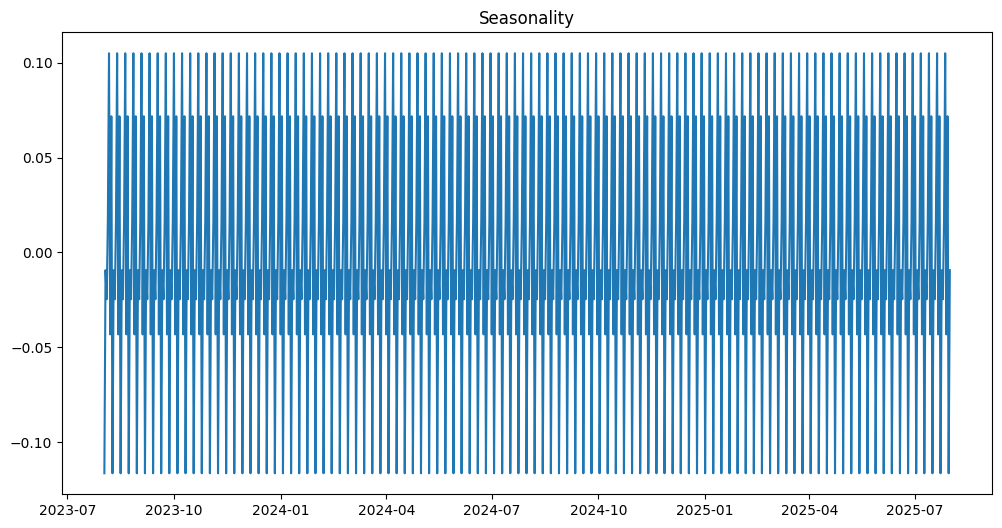

In [20]:
#Seasonality
#the presence or lack of a seasonal component
decomposed_data= seasonal_decompose(Teleco_df_diff)
plt.figure(figsize=(12,6))
plt.title('Seasonality')
plt.plot(decomposed_data.seasonal)


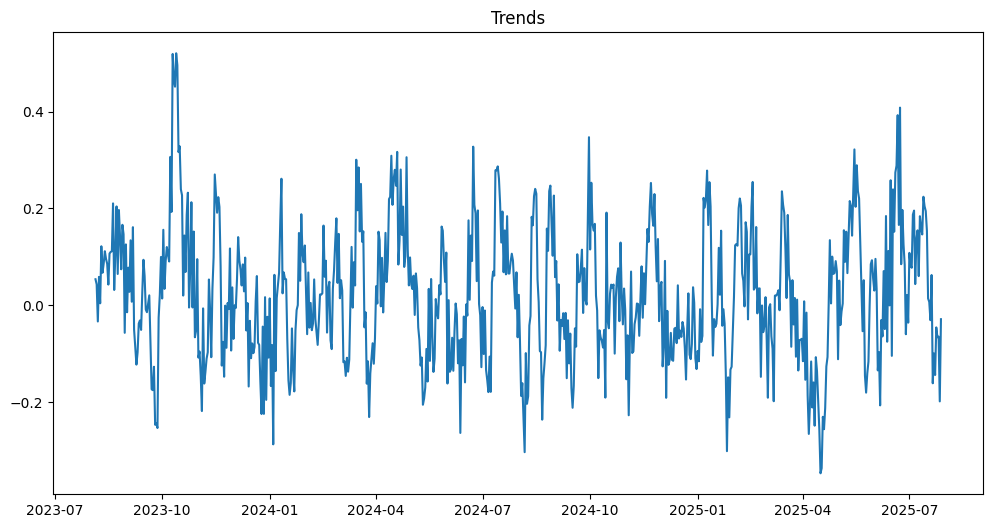

In [21]:
#Trends
plt.figure(figsize=(12,6))
plt.title('Trends')
plt.plot(decomposed_data.trend);

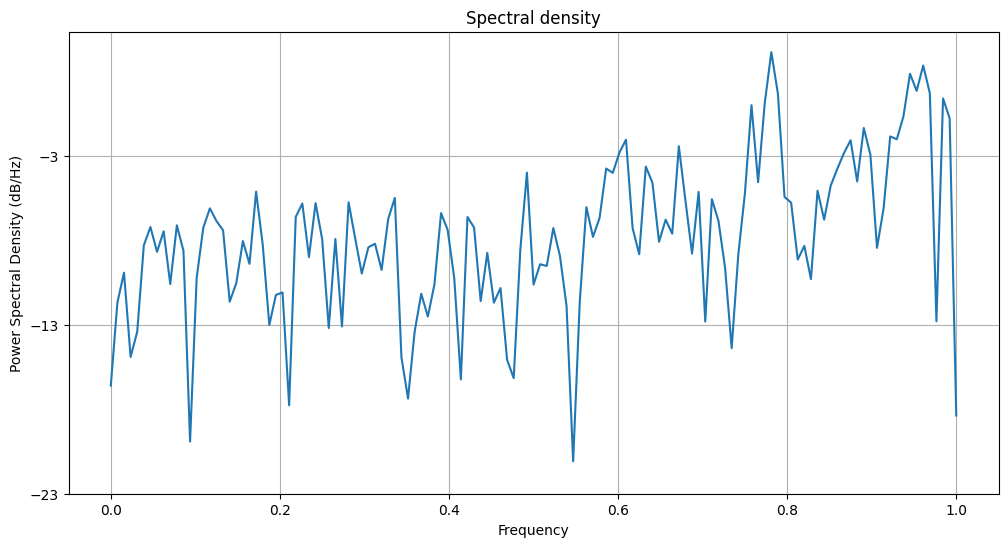

Teleco Spectral dataframe
     Frequency     Power
0     0.000000  0.000000
1     0.001370  0.107302
2     0.002740  0.179280
3     0.004110  0.177296
4     0.005479  0.012843
5     0.006849  0.408582
6     0.008219  0.235838
7     0.009589  0.201203
8     0.010959  0.090099
9     0.012329  0.272280
10    0.013699  0.057737
11    0.015068  0.123510
12    0.016438  0.058434
13    0.017808  0.572680
14    0.019178  0.775726
15    0.020548  0.496580
16    0.021918  0.385218
17    0.023288  0.429538
18    0.024658  0.501061
19    0.026027  0.179268
20    0.027397  0.026811
21    0.028767  0.155080
22    0.030137  0.227005
23    0.031507  0.398160
24    0.032877  0.444933
25    0.034247  0.292125
26    0.035616  0.021805
27    0.036986  0.135135
28    0.038356  0.149711
29    0.039726  0.609167
30    0.041096  0.369967
31    0.042466  0.168094
32    0.043836  0.153662
33    0.045205  0.044419
34    0.046575  0.041769
35    0.047945  0.164504
36    0.049315  0.423515
37    0.050685  0.058710

In [22]:
# the spectral density

plt.figure(figsize=(12,6))
plt.title('Spectral density')
plt.psd(x=Teleco_df_diff.Revenue)
plt.show()

frequencies,power= periodogram(x=Teleco_df_diff.Revenue)
Teleco_Spectral_df= pd.DataFrame({'Frequency':frequencies, 'Power':np.round(power,10)})
pd.set_option('display.max_rows', None)
print("Teleco Spectral dataframe")
print(Teleco_Spectral_df)
print ("  ")
#REMOVING NULLS FROM FREQUENCY and power
Frequency = frequencies[frequencies > 0]
Power = power[frequencies > 0]
dominant_frequency = Frequency[np.argmax(Power)]
s = int(round(1 / dominant_frequency))
print(f"Dominant frequency: {dominant_frequency:.6f}")
print(f"Estimated seasonal period (s): {s}")

Autocorrelation function


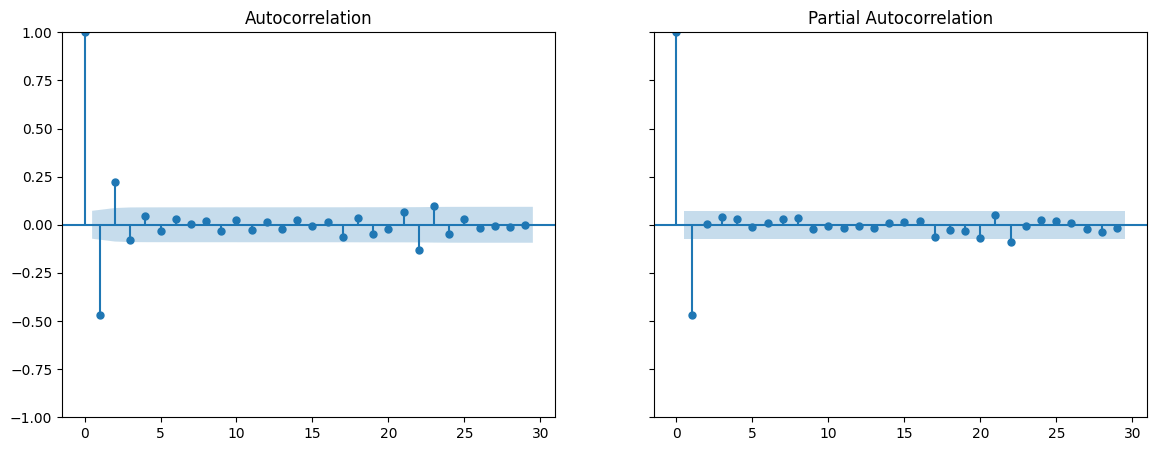

    Lags       ACF      PACF
0      0  1.000000  1.000000
1      1 -0.469506 -0.470150
2      2  0.223874  0.004427
3      3 -0.076620  0.038797
4      4  0.047843  0.032467
5      5 -0.034508 -0.009443
6      6  0.029196  0.007075
7      7  0.004326  0.029870
8      8  0.017328  0.036432
9      9 -0.030830 -0.019598
10    10  0.023792 -0.006319
11    11 -0.027709 -0.018397
12    12  0.013641 -0.007650
13    13 -0.020448 -0.017175
14    14  0.022476  0.007463
15    15 -0.007156  0.013359
16    16  0.016461  0.021423
17    17 -0.064114 -0.065633
18    18  0.035488 -0.029407
19    19 -0.048303 -0.035548
20    20 -0.021149 -0.071277
21    21  0.068434  0.054827
22    22 -0.130043 -0.092892
23    23  0.095537 -0.008714
24    24 -0.046111  0.025421
25    25  0.028504  0.021075
26    26 -0.015962  0.007968
27    27 -0.008878 -0.025269
28    28 -0.012601 -0.036867


In [23]:
#autocorrelation function 
print('Autocorrelation function')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[14,5], sharey=True)
plot_acf(Teleco_df_diff,ax=ax1)
plot_pacf(Teleco_df_diff,ax=ax2)
plt.show()

Acf_Value=acf(Teleco_df_diff)
Pacf_Value=pacf(Teleco_df_diff)

Teleco_lags=list(range(len(Acf_Value)))
Acf_Pacf_df= pd.DataFrame({'Lags':Teleco_lags, 'ACF':Acf_Value,'PACF':Pacf_Value})

print(Acf_Pacf_df)

<Figure size 1800x1000 with 0 Axes>

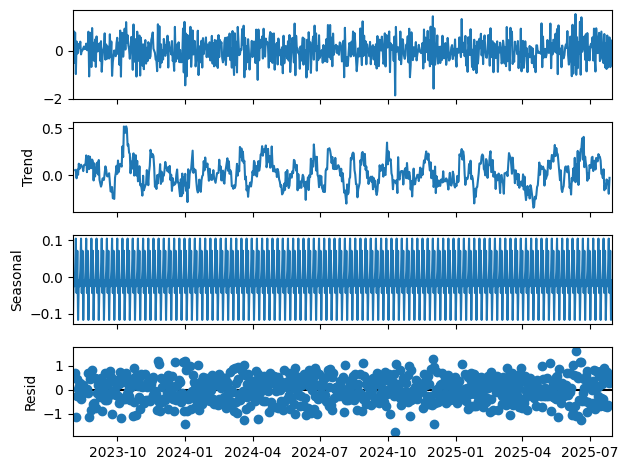

In [24]:
#the decomposed time series
plt.figure(figsize=(18,10))
decomposed_data.plot()
plt.show()

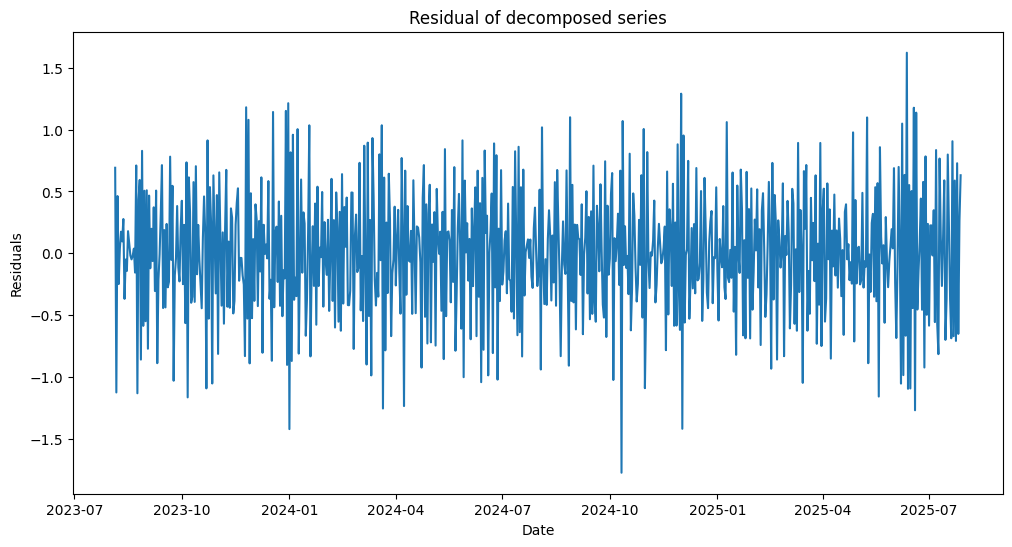

In [25]:
#confirmation of the lack of trends in the residuals of the decomposed series
plt.figure(figsize=(12,6))
plt.title('Residual of decomposed series')
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.plot(decomposed_data.resid)

In [26]:
#Creating the initial model
Initial_model = ARIMA(train_data, order=(1,1,1))
Initial_model_fit = Initial_model.fit()
print(Initial_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                  584
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -387.352
Date:                Tue, 16 Sep 2025   AIC                            780.703
Time:                        22:46:06   BIC                            793.808
Sample:                    08-02-2023   HQIC                           785.811
                         - 03-07-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4587      0.037    -12.556      0.000      -0.530      -0.387
ma.L1         -0.9997      0.098    -10.191      0.000      -1.192      -0.807
sigma2         0.2184      0.024      9.004      0.0

In [27]:
#Determining the best ARIMA model 
Teleco_best_model =auto_arima(train_data,start_p=0, start_q=0,max_p=3, max_q=3, d=None,
                           seasonal= True, stepwise=True, information_criterion='bic',trace=True)
print(Teleco_best_model.summary())

Performing stepwise search to minimize bic
 ARIMA(0,0,0)(0,0,0)[0] intercept   : BIC=919.529, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : BIC=787.002, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : BIC=812.574, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : BIC=914.318, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : BIC=793.366, Time=0.11 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : BIC=793.367, Time=0.10 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : BIC=799.543, Time=0.62 sec
 ARIMA(1,0,0)(0,0,0)[0]             : BIC=783.730, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : BIC=790.098, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : BIC=790.099, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0]             : BIC=809.839, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : BIC=795.977, Time=0.22 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 1.404 seconds
                               SARIMAX Results                                
Dep. Variable:       

In [28]:
#Validating the model selection using the AIC 

Teleco_best_model_aic =auto_arima(train_data,start_p=0, start_q=0,max_p=3, max_q=3, d=None,
                           seasonal= True, stepwise=True, information_criterion='aic',trace=True)
print(Teleco_best_model_aic.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=910.790, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=773.893, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=799.464, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=909.948, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=775.886, Time=0.07 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=775.888, Time=0.09 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=777.694, Time=0.58 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=774.990, Time=0.03 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.963 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  584
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -383.946
Date:                Tue, 16 Sep 2025   AIC                            773.893
Time:                        22:46:08   BIC 

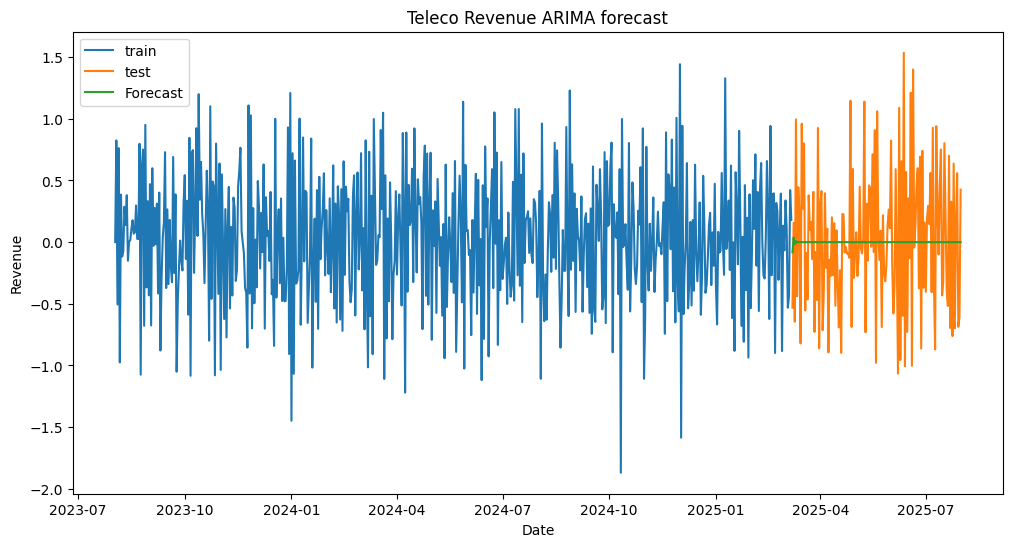

In [29]:
#Using the Test data to forecast
forecast = Teleco_best_model.predict(n_periods=len(test_data))

#forecast = Teleco_best_model.forecast(steps=len(test_data))
plt.figure(figsize=(12,6))
plt.plot(train_data.index, train_data['Revenue'], label='train')
plt.plot(test_data.index, test_data['Revenue'], label='test')
plt.plot(test_data.index, forecast, label='Forecast')
plt.title('Teleco Revenue ARIMA forecast')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.show()

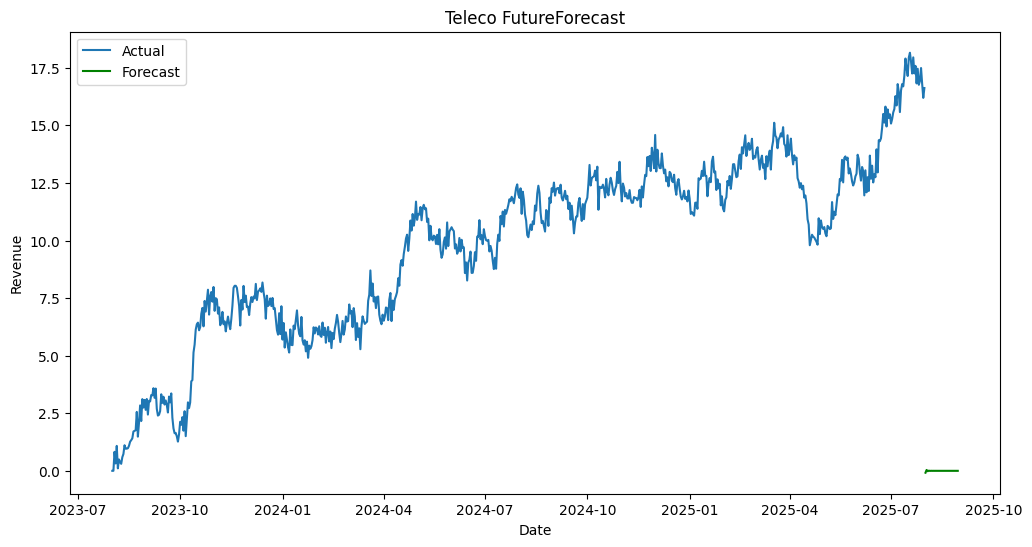

In [30]:
#Using the model to forecast the future
Teleco_future_forecast = Teleco_best_model.predict(n_periods=30)
plt.figure(figsize=(12,6))
plt.plot(Teleco_df.index, Teleco_df['Revenue'], label='Actual')
plt.plot(pd.date_range(start=Teleco_df.index[-1]+pd.Timedelta(days=1), periods=30), Teleco_future_forecast, 
         label='Forecast',color='green')
plt.title('Teleco FutureForecast')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.show()

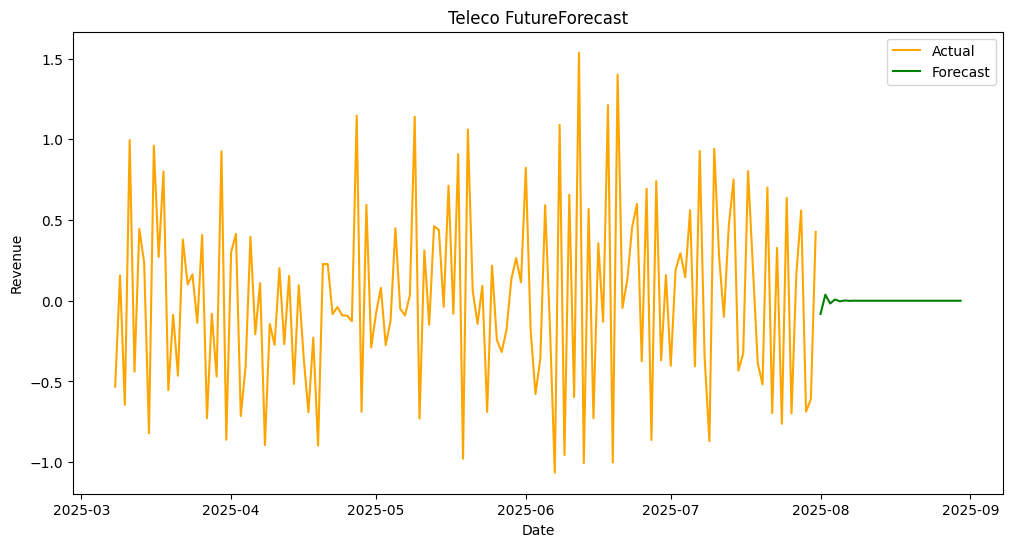

In [31]:
Teleco_future_forecast = Teleco_best_model.predict(n_periods=30)
plt.figure(figsize=(12,6))
plt.plot(test_data.index, test_data['Revenue'], label='Actual',color='orange')
plt.plot(pd.date_range(start=Teleco_df.index[-1]+pd.Timedelta(days=1), periods=30), Teleco_future_forecast, 
         label='Forecast', color='green')
plt.title('Teleco FutureForecast')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.show()

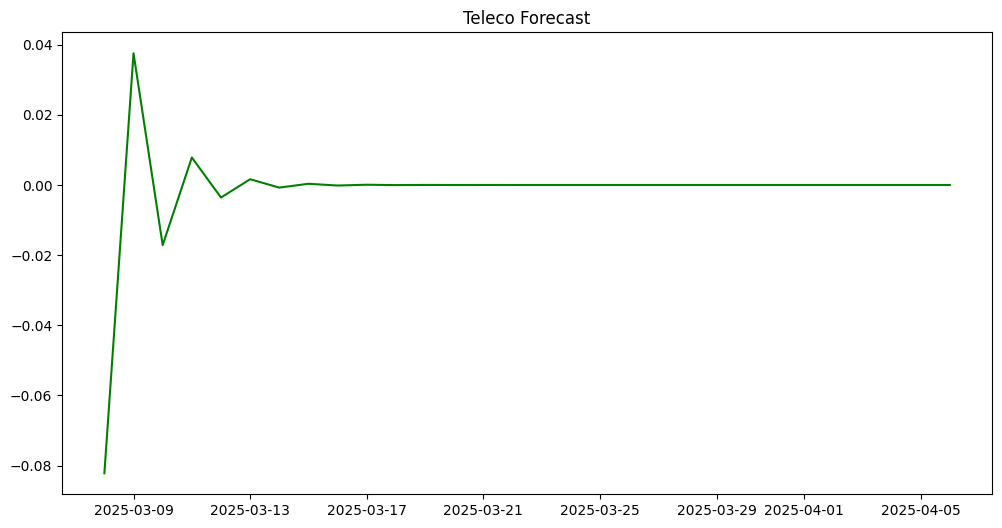

In [32]:
#Forecasting for the next 30 days
future_forecast = Teleco_best_model.predict(n_periods=30)
plt.figure(figsize=(12,6))
plt.plot(future_forecast,color='green')
plt.title('Teleco Forecast')
plt.show()

In [33]:
#Validating the Models perfomance
mse = mean_squared_error(test_data, forecast)
mae = mean_absolute_error(test_data, forecast)
print(f"Mean Squared Error: {mse:.2f}, Mean Absolute Error: {mae:.2f}")
rmse = np.sqrt(mean_squared_error(test_data, forecast))
print("RMSE:", rmse)


Mean Squared Error: 0.32, Mean Absolute Error: 0.47
RMSE: 0.5700310582332536


In [34]:
forecast, confidence_interval = Teleco_best_model.predict(n_periods=30, return_conf_int=True)
Teleco_forecast_confidence_df= pd.DataFrame(
    {'Forecast':np.round(forecast,5), 
     'Lower_ConfidenceInterval':np.round(confidence_interval[:,0],10),
     'Upper_ConfidenceInterval':np.round(confidence_interval[:,1],10)
    })
print(Teleco_forecast_confidence_df)

            Forecast  Lower_ConfidenceInterval  Upper_ConfidenceInterval
2025-03-08  -0.08220                 -0.999676                  0.835275
2025-03-09   0.03755                 -0.971124                  1.046227
2025-03-10  -0.01715                 -1.043841                  1.009532
2025-03-11   0.00784                 -1.022569                  1.038242
2025-03-12  -0.00358                 -1.034760                  1.027600
2025-03-13   0.00164                 -1.029706                  1.032977
2025-03-14  -0.00075                 -1.032122                  1.030628
2025-03-15   0.00034                 -1.031041                  1.031723
2025-03-16  -0.00016                 -1.031539                  1.031228
2025-03-17   0.00007                 -1.031313                  1.031455
2025-03-18  -0.00003                 -1.031416                  1.031351
2025-03-19   0.00001                 -1.031369                  1.031399
2025-03-20  -0.00001                 -1.031391     

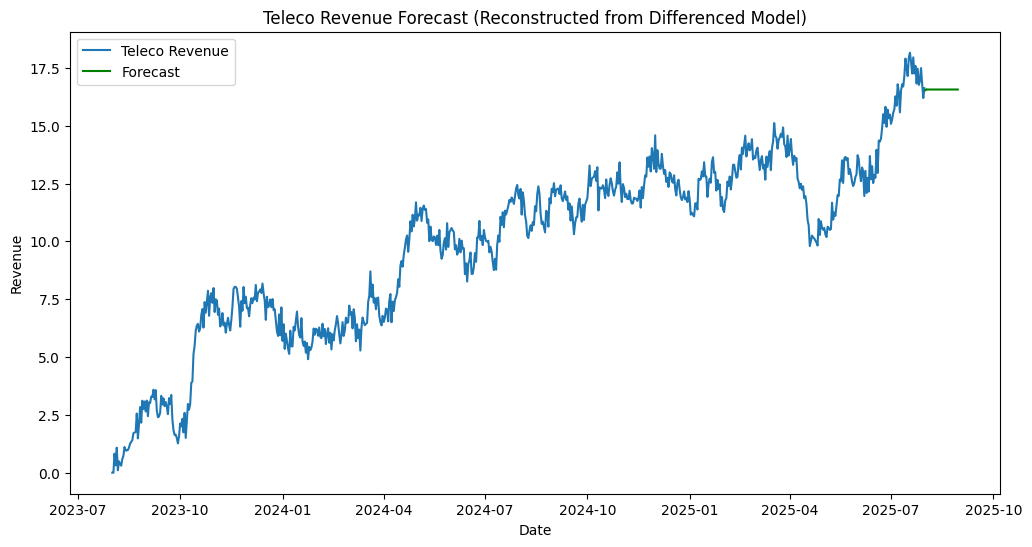

In [35]:
#using the model to predict future revenue values
# Get the last actual value before the forecast starts
last_actual = Teleco_df['Revenue'].iloc[-1]

# Reconstruct original forecast from differenced predictions
reconstructed_forecast = np.r_[last_actual, forecast].cumsum()[1:]

# Create a Series with future dates as index
future_dates = pd.date_range(start=Teleco_df.index[-1] + pd.Timedelta(days=1), periods=len(forecast))
forecast_series = pd.Series(reconstructed_forecast, index=future_dates)

# Plot the reconstructed forecast
plt.figure(figsize=(12,6))
plt.plot(Teleco_df.index, Teleco_df['Revenue'], label='Teleco Revenue')
plt.plot(future_dates, forecast_series, label='Forecast', color='green')
plt.title('Teleco Revenue Forecast (Reconstructed from Differenced Model)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()

plt.show()


In [36]:
# Reconstruct forecast and confidence intervals from differenced output
last_actual = Teleco_df['Revenue'].iloc[-1]

reconstructed_forecast = np.r_[last_actual, forecast].cumsum()[1:]
lower_bound = np.r_[last_actual, confidence_interval[:, 0]].cumsum()[1:]
upper_bound = np.r_[last_actual, confidence_interval[:, 1]].cumsum()[1:]

# Create DataFrame
Teleco_forecast_confidence_df = pd.DataFrame({
    'Forecast': np.round(reconstructed_forecast, 5),
    'Lower_ConfidenceInterval': np.round(lower_bound, 10),
    'Upper_ConfidenceInterval': np.round(upper_bound, 10)
})

print(Teleco_forecast_confidence_df)


    Forecast  Lower_ConfidenceInterval  Upper_ConfidenceInterval
0   16.53860                 15.621122                 17.456073
1   16.57615                 14.649998                 18.502300
2   16.55899                 13.606158                 19.511832
3   16.56683                 12.583589                 20.550074
4   16.56325                 11.548829                 21.577674
5   16.56489                 10.519123                 22.610650
6   16.56414                  9.487001                 23.641278
7   16.56448                  8.455960                 24.673001
8   16.56432                  7.424421                 25.704229
9   16.56440                  6.393108                 26.735684
10  16.56436                  5.361692                 27.767036
11  16.56438                  4.330323                 28.798434
12  16.56437                  3.298932                 29.829811
13  16.56437                  2.267551                 30.861198
14  16.56437             